# NYC Jobs Assessment

**Dataset:** NYC job postings (internal + external) from the City of New York.

**Sections:**
1. Setup & Data Ingestion
2. Utility Functions (reusable across notebook)
3. Data Exploration & Profiling
4. KPIs (6 business questions)
5. Data Processing (cleaning, feature engineering, feature removal, save to target)
6. Test Cases

**Note: I have made some assumptions, which are documented in MyDocument.md**

---
## 1. Setup & Data Ingestion

In [317]:
# After development of all Kpi and explorations all imports consolidated here
import findspark
findspark.init()

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession

from pyspark.sql.window import Window

from pyspark.sql.functions import (
    col, lit, when, trim, lower, length,
    count, countDistinct, mean, sum as spark_sum,
    min as spark_min, max as spark_max,
    coalesce, greatest, regexp_replace,
    explode, split, row_number, add_months,
    year, month, round as spark_round,
    isnan, isnull
)

In [284]:
spark = SparkSession.builder.appName("pyspark-assesment").getOrCreate()

### Read CSV data
- **multiLine=True**: quoted fields can span lines.
- **quote + escape**: handles commas and `""` inside quoted fields so columns don't shift.

In [285]:
CSV_PATH = "/dataset/nyc-jobs.csv"

df_raw = (
    spark.read
    .option("header", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .csv(CSV_PATH)
)

---
## 2. Utility Functions
Reusable functions for column name cleanup, null/empty checks, salary derivation, and category normalization.

In [286]:
# Column name utilities

def fix_csv_column_names(df, expected_names):
    """Strip CR/LF from column names, here replacing empty names from expected list defined in cell below this cell."""
    cr, lf = chr(13), chr(10)
    for i, c in enumerate(df.columns):
        clean = c.strip().strip(cr + lf)
        if not clean and i < len(expected_names):
            clean = expected_names[i]
        if c != clean:
            df = df.withColumnRenamed(c, clean)
    return df


def rename_columns(df, rename_map):
    """Rename columns using a dict {old_name: new_name}."""
    for old_name, new_name in rename_map.items():
        df = df.withColumnRenamed(old_name, new_name)
    return df


# Null/empty check utilities 

def is_null_or_empty(column):
    """Return a boolean Column expression: True when column is null or empty/whitespace string."""
    return col(column).isNull() | (trim(col(column)) == "")


def fill_null_or_empty(column, default):
    """Return column expression: replace null/empty with default value."""
    return when(is_null_or_empty(column), lit(default)).otherwise(col(column))


def null_count_report(df):
    """Return a DataFrame with null/empty count per column."""
    exprs = []
    for c in df.columns:
        dtype = dict(df.dtypes)[c]
        if dtype == "string":
            exprs.append(spark_sum(when(is_null_or_empty(c), 1).otherwise(0)).alias(c))
        else:
            exprs.append(spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c))
    return df.agg(*exprs)


# Date cleaning utility

def clean_and_cast_timestamp(column_name):
    """Strip CR/LF from date strings then cast to timestamp (Spark trim() does not remove CR/LF)."""
    cr, lf = chr(13), chr(10)
    pattern = "[" + cr + lf + "]+"
    return regexp_replace(trim(col(column_name)), pattern, "").cast("timestamp")


# Salary utilities

def add_salary_midpoint(df, from_col="salary_range_from", to_col="salary_range_to", out_col="salary_mid"):
    """Add salary midpoint column: avg of from/to when both exist, else whichever is available."""
    return df.withColumn(
        out_col,
        when(
            col(from_col).isNotNull() & col(to_col).isNotNull(),
            (col(from_col) + col(to_col)) / 2
        ).when(col(from_col).isNotNull(), col(from_col))
         .otherwise(col(to_col))
    )


def add_salary_max(df, from_col="salary_range_from", to_col="salary_range_to", out_col="salary_max"):
    """Add salary max column: greatest of from/to (nulls coalesced to 0)."""
    return df.withColumn(
        out_col,
        greatest(
            coalesce(col(from_col), lit(0.0)),
            coalesce(col(to_col), lit(0.0))
        )
    )


# Category normalization 

def normalize_category(df, src_col="job_category", out_col="category", default="Unspecified"):
    """Replace null/empty job_category with a default label."""
    return df.withColumn(out_col, fill_null_or_empty(src_col, default))


# ---- Education level inference ----

def add_education_level(df, src_col="minimum_qual_requirements", out_col="education_level"):
    """Infer education level from minimum qualification text using keyword matching.
    Assumption: text mentioning PhD > Master > Bachelor in priority order."""
    mq = lower(col(src_col))
    return df.withColumn(
        out_col,
        when(mq.rlike("phd|doctoral|doctorate"), "PhD / Doctoral")
        .when(mq.rlike("master|m\\.?b\\.?a|m\\.?s\\.?|m\\.?a\\.?|graduate degree"), "Master / Graduate")
        .when(mq.rlike("baccalaureate|bachelor|b\\.?s\\.?|b\\.?a\\.?|four.year|4.year|college degree"), "Bachelor")
        .when(is_null_or_empty(src_col), "Not specified")
        .otherwise("Other / No degree mentioned")
    )

### Apply column name fixes, renames, and type casts

In [287]:
EXPECTED_COLUMNS = [
    "Job ID", "Agency", "Posting Type", "# Of Positions", "Business Title",
    "Civil Service Title", "Title Code No", "Level", "Job Category",
    "Full-Time/Part-Time indicator", "Salary Range From", "Salary Range To",
    "Salary Frequency", "Work Location", "Division/Work Unit", "Job Description",
    "Minimum Qual Requirements", "Preferred Skills", "Additional Information",
    "To Apply", "Hours/Shift", "Work Location 1", "Recruitment Contact",
    "Residency Requirement", "Posting Date", "Post Until", "Posting Updated", "Process Date"
]

COLUMN_RENAMES = {
    "Job ID": "job_id", "Agency": "agency", "Posting Type": "posting_type",
    "# Of Positions": "num_of_positions", "Business Title": "business_title",
    "Civil Service Title": "civil_service_title", "Title Code No": "title_code_no",
    "Level": "level", "Job Category": "job_category",
    "Full-Time/Part-Time indicator": "full_time_part_time_indicator",
    "Salary Range From": "salary_range_from", "Salary Range To": "salary_range_to",
    "Salary Frequency": "salary_frequency", "Work Location": "work_location",
    "Division/Work Unit": "division_work_unit", "Job Description": "job_description",
    "Minimum Qual Requirements": "minimum_qual_requirements",
    "Preferred Skills": "preferred_skills", "Additional Information": "additional_information",
    "To Apply": "to_apply", "Hours/Shift": "hours_shift",
    "Work Location 1": "work_location_1", "Recruitment Contact": "recruitment_contact",
    "Residency Requirement": "residency_requirement", "Posting Date": "posting_date",
    "Post Until": "post_until", "Posting Updated": "posting_updated",
    "Process Date": "process_date",
}

DATE_COLUMNS = ["posting_date", "post_until", "posting_updated", "process_date"]

# Fix CR/LF in header names
df = fix_csv_column_names(df_raw, EXPECTED_COLUMNS)

# Rename to spark column name types ex: Job ID is mapped as job_id
df = rename_columns(df, COLUMN_RENAMES)

# Casting numeric and date types
df = (df
    .withColumn("num_of_positions", col("num_of_positions").cast("int"))
    .withColumn("salary_range_from", col("salary_range_from").cast("double"))
    .withColumn("salary_range_to", col("salary_range_to").cast("double"))
)
for dc in DATE_COLUMNS:
    df = df.withColumn(dc, clean_and_cast_timestamp(dc))

df.printSchema()

root
 |-- job_id: string (nullable = true)
 |-- agency: string (nullable = true)
 |-- posting_type: string (nullable = true)
 |-- num_of_positions: integer (nullable = true)
 |-- business_title: string (nullable = true)
 |-- civil_service_title: string (nullable = true)
 |-- title_code_no: string (nullable = true)
 |-- level: string (nullable = true)
 |-- job_category: string (nullable = true)
 |-- full_time_part_time_indicator: string (nullable = true)
 |-- salary_range_from: double (nullable = true)
 |-- salary_range_to: double (nullable = true)
 |-- salary_frequency: string (nullable = true)
 |-- work_location: string (nullable = true)
 |-- division_work_unit: string (nullable = true)
 |-- job_description: string (nullable = true)
 |-- minimum_qual_requirements: string (nullable = true)
 |-- preferred_skills: string (nullable = true)
 |-- additional_information: string (nullable = true)
 |-- to_apply: string (nullable = true)
 |-- hours_shift: string (nullable = true)
 |-- work_loca

---
## 3. Data Exploration & Profiling

Analysis of source data -  column types, categorical analysis, null and other basic stats.

### Row count and column summary

In [321]:
total_rows = df.count()
total_cols = len(df.columns)
print(f"Total rows: {total_rows}")
print(f"Total columns: {total_cols}")
print()

# Column types summary
type_counts = {}
for name, dtype in df.dtypes:
    type_counts[dtype] = type_counts.get(dtype, 0) + 1
print("Column type distribution:")
for dtype, cnt in sorted(type_counts.items()):
    print(f"  {dtype}: {cnt}")
print()

# Classify columns
numeric_cols = [n for n, t in df.dtypes if t in ("int", "double", "float", "long")]
date_cols = [n for n, t in df.dtypes if t in ("timestamp", "date")]
text_cols = [n for n, t in df.dtypes if t == "string"]

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Date columns ({len(date_cols)}): {date_cols}")
print(f"Text/String columns ({len(text_cols)}): {text_cols}")

Total rows: 2946
Total columns: 28

Column type distribution:
  double: 2
  int: 1
  string: 21
  timestamp: 4

Numeric columns (3): ['num_of_positions', 'salary_range_from', 'salary_range_to']
Date columns (4): ['posting_date', 'post_until', 'posting_updated', 'process_date']
Text/String columns (21): ['job_id', 'agency', 'posting_type', 'business_title', 'civil_service_title', 'title_code_no', 'level', 'job_category', 'full_time_part_time_indicator', 'salary_frequency', 'work_location', 'division_work_unit', 'job_description', 'minimum_qual_requirements', 'preferred_skills', 'additional_information', 'to_apply', 'hours_shift', 'work_location_1', 'recruitment_contact', 'residency_requirement']


### Null/empty count for each column

In [322]:
null_report = null_count_report(df)
null_report.show(1, False, True)

-RECORD 0-----------------------------
 job_id                        | 0    
 agency                        | 0    
 posting_type                  | 0    
 num_of_positions              | 0    
 business_title                | 0    
 civil_service_title           | 0    
 title_code_no                 | 0    
 level                         | 0    
 job_category                  | 2    
 full_time_part_time_indicator | 195  
 salary_range_from             | 0    
 salary_range_to               | 0    
 salary_frequency              | 0    
 work_location                 | 0    
 division_work_unit            | 0    
 job_description               | 0    
 minimum_qual_requirements     | 20   
 preferred_skills              | 393  
 additional_information        | 1092 
 to_apply                      | 1    
 hours_shift                   | 2062 
 work_location_1               | 1588 
 recruitment_contact           | 2946 
 residency_requirement         | 4    
 posting_date            

### Numeric column statistics

In [323]:
df.select(numeric_cols).describe().show()

+-------+------------------+-----------------+-----------------+
|summary|  num_of_positions|salary_range_from|  salary_range_to|
+-------+------------------+-----------------+-----------------+
|  count|              2946|             2946|             2946|
|   mean|2.4959266802443993|58904.13979385607|85535.71162739318|
| stddev|  9.28131282646684|26986.57593579136|42871.31345366742|
|    min|                 1|              0.0|            10.36|
|    max|               200|         218587.0|         234402.0|
+-------+------------------+-----------------+-----------------+



### Date range check

In [291]:
date_range_exprs = []
for dc in DATE_COLUMNS:
    date_range_exprs.extend([
        spark_min(dc).alias(f"min_{dc}"),
        spark_max(dc).alias(f"max_{dc}")
    ])
df.agg(*date_range_exprs).show(1, False, True)

-RECORD 0----------------------------------
 min_posting_date    | 2011-06-24 00:00:00 
 max_posting_date    | 2019-12-17 00:00:00 
 min_post_until      | 2019-12-18 00:00:00 
 max_post_until      | 2020-12-11 00:00:00 
 min_posting_updated | 2011-06-24 00:00:00 
 max_posting_updated | 2019-12-16 00:00:00 
 min_process_date    | 2019-12-17 00:00:00 
 max_process_date    | 2019-12-17 00:00:00 



### Categorical columns: distinct counts

In [292]:
# Columns with a limited set of repeated values (low cardinality)
categorical_candidates = [
    "agency", "posting_type", "job_category", "salary_frequency",
    "full_time_part_time_indicator", "level"
]

for c in categorical_candidates:
    distinct_count = df.select(c).distinct().count()
    print(f"{c}: {distinct_count} distinct values")

agency: 52 distinct values
posting_type: 2 distinct values
job_category: 131 distinct values
salary_frequency: 3 distinct values
full_time_part_time_indicator: 3 distinct values
level: 14 distinct values


In [293]:
# checking actual values for low-cardinality columns
df.select("salary_frequency").distinct().show()
df.select("posting_type").distinct().show()
df.select("full_time_part_time_indicator").distinct().show()

+----------------+
|salary_frequency|
+----------------+
|          Annual|
|           Daily|
|          Hourly|
+----------------+

+------------+
|posting_type|
+------------+
|    Internal|
|    External|
+------------+

+-----------------------------+
|full_time_part_time_indicator|
+-----------------------------+
|                            F|
|                         null|
|                            P|
+-----------------------------+



### Duplicate check

In [325]:
# Check if same job_id can appear for both Internal and External posting
total_job_ids = df.select("job_id").count()
distinct_job_ids = df.select("job_id").distinct().count()
print(f"Total rows: {total_job_ids}")
print(f"Distinct job_ids: {distinct_job_ids}")
print(f"Duplicate rows, same job_id with different posting type): {total_job_ids - distinct_job_ids}")

Total rows: 2946
Distinct job_ids: 1661
Duplicate rows, same job_id with different posting type): 1285


---
## 4. KPIs

###  1: Number of job postings per category (Top 10)
**Assumption:** Internal + External postings both counted. Null/empty category set to "Unspecified".

In [326]:
jobs_per_category = (
    normalize_category(df)
    .groupBy("category")
    .agg(count("job_id").alias("job_count"))
    .orderBy(col("job_count").desc())
    .limit(10)
)
jobs_per_category.show(10, False)

+-----------------------------------------+---------+
|category                                 |job_count|
+-----------------------------------------+---------+
|Engineering, Architecture, & Planning    |504      |
|Technology, Data & Innovation            |313      |
|Legal Affairs                            |226      |
|Public Safety, Inspections, & Enforcement|182      |
|Building Operations & Maintenance        |181      |
|Finance, Accounting, & Procurement       |169      |
|Administration & Human Resources         |134      |
|Constituent Services & Community Programs|129      |
|Health                                   |125      |
|Policy, Research & Analysis              |124      |
+-----------------------------------------+---------+



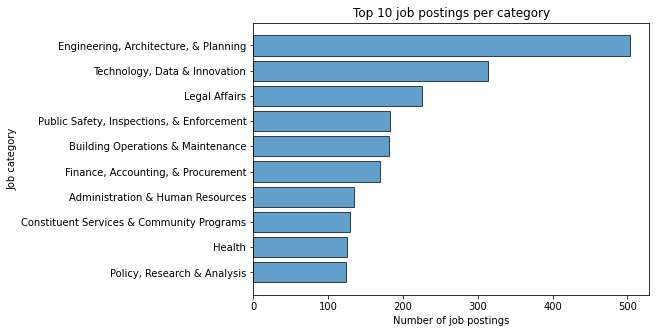

In [327]:
pdf = jobs_per_category.toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pdf["category"], pdf["job_count"], edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of job postings")
ax.set_ylabel("Job category")
ax.set_title("Top 10 job postings per category")
ax.invert_yaxis()
plt.subplots_adjust(left=0.35)
plt.show()

### 2: Salary distribution per job category
**Assumption:** Salary as midpoint of `salary_range_from` and `salary_range_to`. If only one is available, use that. Rows with no salary excluded.

In [328]:
df_kpi2 = normalize_category(add_salary_midpoint(df))

salary_dist_by_category = (
    df_kpi2
    .filter(col("salary_mid").isNotNull())
    .groupBy("category")
    .agg(
        spark_min("salary_mid").alias("min_salary"),
        spark_max("salary_mid").alias("max_salary"),
        spark_round(mean("salary_mid"), 2).alias("avg_salary"),
        count("*").alias("posting_count")
    )
    .orderBy(col("avg_salary").desc())
)
salary_dist_by_category.show(20, False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-------------+
|category                                                                                                                                                                                                 |min_salary|max_salary|avg_salary|posting_count|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-------------+
|Administration & Human Resources Finance, Accounting, & Procurement Building Operations & Maintenance                                                                                                    |218587.0  |218587.0  |218587.0  |2          

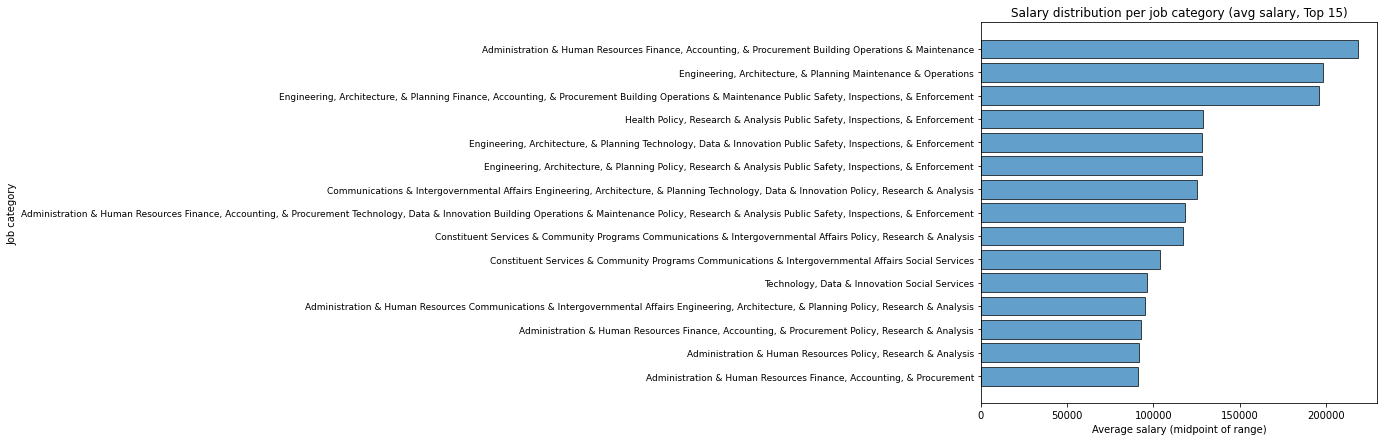

In [329]:
pdf = salary_dist_by_category.limit(15).toPandas()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["category"], pdf["avg_salary"], edgecolor="black", alpha=0.7)
ax.set_xlabel("Average salary (midpoint of range)")
ax.set_ylabel("Job category")
ax.set_title("Salary distribution per job category (avg salary, Top 15)")
ax.invert_yaxis()
plt.subplots_adjust(left=0.35)
plt.setp(ax.get_yticklabels(), fontsize=9)
plt.show()

### KPI 3: Correlation between higher degree and salary
**Assumption:** Education level is inferred from `minimum_qual_requirements` text using keyword regex as there is no explicit degree column. 

**Priority:** PhD > Master > Bachelor > Other. Salary = midpoint.

In [330]:
df_kpi3 = add_education_level(add_salary_midpoint(df))
df_kpi3 = df_kpi3.filter(col("salary_mid").isNotNull())

edu_salary = (
    df_kpi3
    .groupBy("education_level")
    .agg(
        spark_round(mean("salary_mid"), 2).alias("avg_salary"),
        count("*").alias("count")
    )
    .orderBy(col("avg_salary").desc())
)
edu_salary.show(20, False)

+---------------------------+----------+-----+
|education_level            |avg_salary|count|
+---------------------------+----------+-----+
|Not specified              |90243.35  |20   |
|PhD / Doctoral             |83775.48  |85   |
|Master / Graduate          |72815.75  |2337 |
|Bachelor                   |69451.76  |391  |
|Other / No degree mentioned|57593.53  |113  |
+---------------------------+----------+-----+



In [331]:
# Numeric correlation: encode education level as ordinal and compute Pearson correlation
from pyspark.sql.functions import corr

df_corr = df_kpi3.withColumn(
    "education_num",
    when(col("education_level") == "PhD / Doctoral", 3)
    .when(col("education_level") == "Master / Graduate", 2)
    .when(col("education_level") == "Bachelor", 1)
    .otherwise(0)
)
df_corr.select(corr("education_num", "salary_mid").alias("degree_salary_correlation")).show()
# Here positive value shows higher degree requirements tend to have higher salaries

+-------------------------+
|degree_salary_correlation|
+-------------------------+
|      0.08725525466963437|
+-------------------------+



### KPI 4: Job posting with highest salary per agency
**Assumption:** Salary = max(salary_range_from, salary_range_to). Uses `row_number()` window for exactly one posting per agency.

In [332]:
df_kpi4 = add_salary_max(df).filter(col("salary_max") > 0)

window_spec = Window.partitionBy("agency").orderBy(col("salary_max").desc(), col("job_id").asc())

highest_posting_per_agency = (
    df_kpi4
    .withColumn("rn", row_number().over(window_spec))
    .filter(col("rn") == 1)
    .drop("rn")
    .select(
        "agency", "job_id", "business_title", "job_category",
        "salary_max", "salary_range_from", "salary_range_to",
        "salary_frequency", "posting_type", "posting_date"
    )
    .orderBy(col("salary_max").desc())
)
highest_posting_per_agency.show(50, False)

+------------------------------+------+------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------+----------+-----------------+---------------+----------------+------------+-------------------+
|agency                        |job_id|business_title                                              |job_category                                                                                                                              |salary_max|salary_range_from|salary_range_to|salary_frequency|posting_type|posting_date       |
+------------------------------+------+------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------+----------+-----------------+---------------+----------------+------------+----------------

### KPI 5: Average salary per agency for the last 2 years
**Assumption:** "Last 2 years" = from (max posting_date in dataset) minus 24 months. Salary = max(salary_range_from, salary_range_to). Rows with null posting_date are excluded.

In [304]:
df_kpi5 = add_salary_max(df).filter((col("salary_max") > 0) & col("posting_date").isNotNull())

# Compute data only for max(posting_date) - 24 months
max_date = df_kpi5.agg(spark_max("posting_date")).collect()[0][0]
cutoff = add_months(lit(max_date), -24)
print(f"Max posting_date: {max_date}, cutoff (last 2 years): using max_date - 24 months")

avg_salary_per_agency = (
    df_kpi5
    .filter(col("posting_date") >= cutoff)
    .groupBy("agency")
    .agg(
        spark_round(mean("salary_max"), 2).alias("avg_salary"),
        count("*").alias("posting_count")
    )
    .orderBy(col("avg_salary").desc())
)
avg_salary_per_agency.show(50, False)

Max posting_date: 2019-12-17 00:00:00, cutoff (last 2 years): using max_date - 24 months
+------------------------------+----------+-------------+
|agency                        |avg_salary|posting_count|
+------------------------------+----------+-------------+
|CONFLICTS OF INTEREST BOARD   |170000.0  |2            |
|NYC EMPLOYEES RETIREMENT SYS  |118241.22 |36           |
|DEPT OF DESIGN & CONSTRUCTION |114836.08 |142          |
|DEPT OF INFO TECH & TELECOMM  |113832.52 |90           |
|FINANCIAL INFO SVCS AGENCY    |111769.48 |31           |
|NYC HOUSING AUTHORITY         |107087.58 |214          |
|BOARD OF CORRECTION           |102936.0  |2            |
|MAYORS OFFICE OF CONTRACT SVCS|99357.14  |28           |
|DEPARTMENT OF PROBATION       |94618.1   |23           |
|LAW DEPARTMENT                |92246.99  |72           |
|NYC DEPT OF VETERANS' SERVICES|92001.0   |2            |
|DEPARTMENT OF FINANCE         |90428.92  |24           |
|BUSINESS INTEGRITY COMMISSION |87857.14 

### KPI 6: Highest paid skills in the US market
**Assumption:** Data is NYC only; interpreted as "highest paid skills in this NYC dataset". Skills are parsed from `preferred_skills` text by splitting on common delimiters (bullets, numbering, semicolons). Here I am keeping limit to atleast 3 postings per skill for relevance of data.

In [340]:
df_kpi6 = add_salary_max(df).filter(col("salary_max") > 0)

# Parse preferred_skills into individual skill phrases, using regex to remove and get a list of skills.
df_skills = (
    df_kpi6
    .filter(~is_null_or_empty("preferred_skills"))
    .select("job_id", "salary_max", "preferred_skills")
    .withColumn("skills_text", lower(trim(col("preferred_skills"))))
    .withColumn("skills_text",regexp_replace(col("skills_text"),"[\\uFEFF\\u200B\\u200E\\u200F]",""))
    .withColumn("skills_text", regexp_replace(col("skills_text"), "â€¢|•", "|"))
    .withColumn("skills_text", regexp_replace(col("skills_text"), "\\d+\\.\\s*", "|"))  # 1. 2. -> |
    .withColumn("skills_text", regexp_replace(col("skills_text"), "[;]", "|"))
    .withColumn("skills_text", regexp_replace(col("skills_text"), "\\s{2,}", "|"))  # double space -> |
    .withColumn("skill", explode(split(col("skills_text"), "\\|")))
    .withColumn("skill", trim(col("skill")))
    .filter(length(col("skill")) >= 5)
    .select("job_id", "salary_max", "skill")
)

highest_paid_skills = (
    df_skills
    .groupBy("skill")
    .agg(
        spark_round(mean("salary_max"), 2).alias("avg_salary"),
        count("*").alias("posting_count")
    )
    .filter(col("posting_count") >= 3)
    .orderBy(col("avg_salary").desc())
)
highest_paid_skills.show(20, False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+-------------+
|skill                                                                                                                                                                                                                                                                                                                                                                                                                                                       |avg_salary|posting_count|
+-------------------------------------------------------

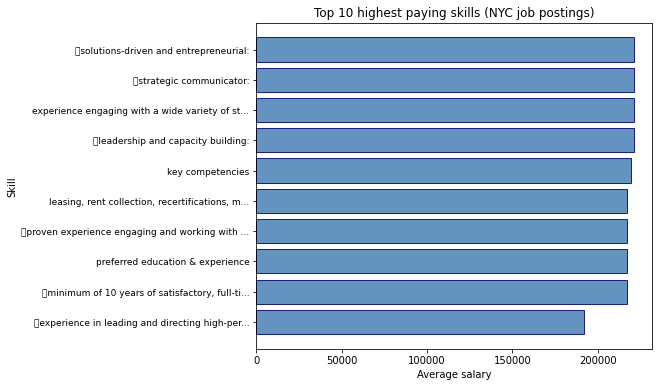

In [341]:
top10 = highest_paid_skills.limit(10).toPandas()
top10["skill_short"] = top10["skill"].str[:45] + (top10["skill"].str.len() > 45).map({True: "...", False: ""})

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10["skill_short"], top10["avg_salary"], color="steelblue", edgecolor="navy", alpha=0.85)
ax.set_xlabel("Average salary")
ax.set_ylabel("Skill")
ax.set_title("Top 10 highest paying skills (NYC job postings)")
ax.invert_yaxis()
plt.subplots_adjust(left=0.35)
plt.setp(ax.get_yticklabels(), fontsize=9)
plt.show()

---
## 5. Data Processing

Functions for cleaning, feature engineering, feature removal, and saving processed data.

###  Cleaning functions
These functions encapsulate the cleaning steps applied above so they can be reused or tested independently.

In [308]:
def clean_dataframe(df):
    """Apply all cleaning steps to the raw DataFrame.
    Steps:
      1. Fix CR/LF in column names
      2. Rename to snake_case
      3. Cast numeric and date types
      4. Trim leading/trailing whitespace from all string columns
    """
    df = fix_csv_column_names(df, EXPECTED_COLUMNS)
    df = rename_columns(df, COLUMN_RENAMES)

    df = (df
        .withColumn("num_of_positions", col("num_of_positions").cast("int"))
        .withColumn("salary_range_from", col("salary_range_from").cast("double"))
        .withColumn("salary_range_to", col("salary_range_to").cast("double"))
    )
    for dc in DATE_COLUMNS:
        df = df.withColumn(dc, clean_and_cast_timestamp(dc))

    # Trim whitespace from all remaining string columns
    for name, dtype in df.dtypes:
        if dtype == "string":
            df = df.withColumn(name, trim(col(name)))

    return df

###  Feature Engineering

feature engineering techniques applied:

1. **Salary midpoint** — `(salary_range_from + salary_range_to) / 2` — a single salary metric for analysis.
2. **Salary spread** — `salary_range_to - salary_range_from` — measures negotiation/flexibility range.
3. **Posting year and month** — extracted from `posting_date` for time-based analysis.
4. **Education level** — inferred from `minimum_qual_requirements` text using keyword regex.
5. **Has preferred skills flag** — binary indicator whether `preferred_skills` is provided.

In [342]:
def apply_feature_engineering(df):
    """Apply feature engineering techniques.
    Features added:
      - salary_mid:      midpoint of salary_range_from and salary_range_to
      - salary_spread:   salary_range_to - salary_range_from
      - posting_year:    year extracted from posting_date
      - posting_month:   month extracted from posting_date
      - education_level: inferred from minimum_qual_requirements
      - has_preferred_skills: 1 if preferred_skills is not null/empty, else 0
    """
    # Salary midpoint
    df = add_salary_midpoint(df)

    # Salary spread (negotiation range)
    df = df.withColumn(
        "salary_spread",
        when(
            col("salary_range_from").isNotNull() & col("salary_range_to").isNotNull(),
            col("salary_range_to") - col("salary_range_from")
        )
    )

    # Posting year and month
    df = df.withColumn("posting_year", year("posting_date"))
    df = df.withColumn("posting_month", month("posting_date"))

    # Education level from minimum qualifications
    df = add_education_level(df)

    # Has preferred skills flag
    df = df.withColumn(
        "has_preferred_skills",
        when(is_null_or_empty("preferred_skills"), 0).otherwise(1)
    )

    return df

### Feature Removal
Columns removed based on exploration/profiling:

recruitment_contact: >95% null; not useful for analysis.
work_location_1: largely duplicates work_location; mostly null.
to_apply: free-text application instructions; not useful for salary/category analysis.
additional_information: mostly null; supplementary info only.
hours_shift: mostly null; not consistently populated.


In [345]:

COLUMNS_TO_DROP = [
    "recruitment_contact",    # >95% null
    "work_location_1",        # duplicates work_location, mostly null
    "to_apply",               # free-text application instructions
    "additional_information", # mostly null
    "hours_shift",            # mostly null
]

def remove_features(df, columns_to_drop):
    """Drop columns that are redundant, too sparse, or not useful."""
    return df.drop(*columns_to_drop)

###  Build and save processed dataset

In [346]:
# Apply the full processing pipeline
df_processed = clean_dataframe(df_raw)
df_processed = apply_feature_engineering(df_processed)
df_processed = remove_features(df_processed, COLUMNS_TO_DROP)

print(f"Processed DataFrame: {df_processed.count()} rows, {len(df_processed.columns)} columns")
df_processed.printSchema()

Processed DataFrame: 2946 rows, 29 columns
root
 |-- job_id: string (nullable = true)
 |-- agency: string (nullable = true)
 |-- posting_type: string (nullable = true)
 |-- num_of_positions: integer (nullable = true)
 |-- business_title: string (nullable = true)
 |-- civil_service_title: string (nullable = true)
 |-- title_code_no: string (nullable = true)
 |-- level: string (nullable = true)
 |-- job_category: string (nullable = true)
 |-- full_time_part_time_indicator: string (nullable = true)
 |-- salary_range_from: double (nullable = true)
 |-- salary_range_to: double (nullable = true)
 |-- salary_frequency: string (nullable = true)
 |-- work_location: string (nullable = true)
 |-- division_work_unit: string (nullable = true)
 |-- job_description: string (nullable = true)
 |-- minimum_qual_requirements: string (nullable = true)
 |-- preferred_skills: string (nullable = true)
 |-- residency_requirement: string (nullable = true)
 |-- posting_date: timestamp (nullable = true)
 |-- pos

In [347]:
# Save processed data to target file (Parquet for efficient storage and schema preservation)
TARGET_PATH = "/dataset/processed/nyc_jobs_processed.parquet"

df_processed.write.mode("overwrite").parquet(TARGET_PATH)
print(f"Processed data saved in path: {TARGET_PATH}")

Processed data saved in path: /dataset/processed/nyc_jobs_processed.parquet


In [348]:
# Verify: read back and confirm
df_verify = spark.read.parquet(TARGET_PATH)
print(f"Read back: {df_verify.count()} rows, {len(df_verify.columns)} columns")
df_verify.show(3, truncate=50)

Read back: 2946 rows, 29 columns
+------+----------------------------+------------+----------------+--------------------------------------------------+------------------------------+-------------+-----+------------------------+-----------------------------+-----------------+---------------+----------------+----------------------+------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+-------------------+----------+-------------------+-------------------+----------+------------------+------------+-------------+-----------------+--------------------+
|job_id|                      agency|posting_type|num_of_positions|                                    business_title|           civil_service_title|title_code_no|level|            job_category|full_time_part_time_indicator|salary_range_from|salary_range_to|salary_f

---
## 6. Test Cases

Basic tests for utility functions and KPI logic using mock DataFrames.

In [314]:
def get_salary_frequency(df):
    """Return distinct salary frequency values as a list."""
    row_list = df.select("salary_frequency").distinct().collect()
    return [row["salary_frequency"] for row in row_list]

In [349]:
def run_tests():
    passed, failed = 0, 0

    def assert_eq(actual, expected, name):
        nonlocal passed, failed
        if actual == expected:
            passed += 1
            print(f"  PASS: {name}")
        else:
            failed += 1
            print(f"  FAIL: {name} — expected {expected}, got {actual}")

    # Test: rename_columns 
    print("Test rename_columns")
    mock = spark.createDataFrame([(1,)], ["Old Name"])
    result = rename_columns(mock, {"Old Name": "new_name"})
    assert_eq(result.columns, ["new_name"], "renames column correctly")

    # Test: is_null_or_empty 
    print("Test is_null_or_empty")
    mock = spark.createDataFrame(
        [("hello",), (None,), ("",), ("  ",)],
        ["val"]
    )
    counts = mock.filter(is_null_or_empty("val")).count()
    assert_eq(counts, 3, "detects null, empty string, whitespace-only")

    # Test: fill_null_or_empty 
    print("Test fill_null_or_empty")
    mock = spark.createDataFrame([(None,), ("",), ("A",)], ["val"])
    result = mock.withColumn("filled", fill_null_or_empty("val", "default"))
    vals = [r["filled"] for r in result.collect()]
    assert_eq(vals, ["default", "default", "A"], "fills null and empty with default")

    # Test: add_salary_midpoint
    print("Test add_salary_midpoint")
    mock = spark.createDataFrame(
        [(100.0, 200.0), (50.0, None), (None, 80.0), (None, None)],
        ["salary_range_from", "salary_range_to"]
    )
    result = add_salary_midpoint(mock).select("salary_mid").collect()
    mids = [r["salary_mid"] for r in result]
    assert_eq(mids[0], 150.0, "midpoint when both exist")
    assert_eq(mids[1], 50.0, "uses from when to is null")
    assert_eq(mids[2], 80.0, "uses to when from is null")
    assert_eq(mids[3], None, "null when both null")

    # Test: add_salary_max 
    print("Test add_salary_max")
    mock = spark.createDataFrame(
        [(100.0, 200.0), (300.0, None), (None, None)],
        ["salary_range_from", "salary_range_to"]
    )
    result = add_salary_max(mock).select("salary_max").collect()
    maxes = [r["salary_max"] for r in result]
    assert_eq(maxes[0], 200.0, "max of both")
    assert_eq(maxes[1], 300.0, "from when to is null")
    assert_eq(maxes[2], 0.0, "zero when both null")

    # Test: normalize_category 
    print("Test normalize_category")
    mock = spark.createDataFrame(
        [("Engineering",), (None,), ("",)],
        ["job_category"]
    )
    result = normalize_category(mock).select("category").collect()
    cats = [r["category"] for r in result]
    assert_eq(cats, ["Engineering", "Unspecified", "Unspecified"], "replaces null/empty with Unspecified")

    # --- Test: add_education_level ---
    print("Test add_education_level")
    mock = spark.createDataFrame(
        [
            ("PhD in Computer Science required",),
            ("Master degree or MBA preferred",),
            ("Baccalaureate degree from an accredited college",),
            ("3 years of experience",),
            (None,),
        ],
        ["minimum_qual_requirements"]
    )
    result = add_education_level(mock).select("education_level").collect()
    levels = [r["education_level"] for r in result]
    assert_eq(levels[0], "PhD / Doctoral", "detects PhD")
    assert_eq(levels[1], "Master / Graduate", "detects Master/MBA")
    assert_eq(levels[2], "Bachelor", "detects Baccalaureate")
    assert_eq(levels[3], "Other / No degree mentioned", "falls back to Other")
    assert_eq(levels[4], "Not specified", "null input")

    # Test: get_salary_frequency
    print("Test get_salary_frequency")
    mock = spark.createDataFrame([("A", "Annual"), ("B", "Daily")], ["id", "salary_frequency"])
    result = sorted(get_salary_frequency(mock))
    assert_eq(result, ["Annual", "Daily"], "returns distinct frequencies")

    # Test: null_count_report
    print("Test null_count_report")
    mock = spark.createDataFrame(
        [("a", 1), (None, None), ("", 3)],
        ["name", "val"]
    )
    report = null_count_report(mock).collect()[0]
    assert_eq(report["name"], 2, "counts null + empty strings")
    assert_eq(report["val"], 1, "counts numeric nulls")

    print(f"--- Results: {passed} passed, {failed} failed ---")
    assert failed == 0, f"{failed} test(s) failed!"

run_tests()

Test rename_columns
  PASS: renames column correctly
Test is_null_or_empty
  PASS: detects null, empty string, whitespace-only
Test fill_null_or_empty
  PASS: fills null and empty with default
Test add_salary_midpoint
  PASS: midpoint when both exist
  PASS: uses from when to is null
  PASS: uses to when from is null
  PASS: null when both null
Test add_salary_max
  PASS: max of both
  PASS: from when to is null
  PASS: zero when both null
Test normalize_category
  PASS: replaces null/empty with Unspecified
Test add_education_level
  PASS: detects PhD
  PASS: detects Master/MBA
  PASS: detects Baccalaureate
  PASS: falls back to Other
  PASS: null input
Test get_salary_frequency
  PASS: returns distinct frequencies
Test null_count_report
  PASS: counts null + empty strings
  PASS: counts numeric nulls
--- Results: 19 passed, 0 failed ---
